# Task 2: QML Time Series: Insurance Premium Prediction

## What This Notebook Does
Map wildfire risk scores to insurance premiums and predict future premiums using Quantum ML.

## The Task 
> "Conduct a time series analysis using QML to map the wildfire risk score to the two Challenge
> data sets containing insurance premiums. Predict future insurance premiums based on historical data (2018-2021)."

## Approach
1. Load and prepare insurance data (2018-2021) per ZIP code
2. Build classical time series baselines (Linear Regression, XGBoost)
3. Build a **Variational Quantum Regressor (VQR)** — the regression version of VQC
4. Build a **Quantum Kernel Regression** model
5. Compare all approaches

## Key Concepts
- **Regression** = predicting a continuous number (premium amount) instead of a category (fire/no-fire)
- **Time Series** = data ordered by time — we predict 2021 using 2018-2020
- **VQR (Variational Quantum Regressor)** = same idea as VQC but for continuous output. The quantum circuit outputs an expectation value (a number between -1 and +1) instead of a class label.
- **Feature Engineering** = creating new useful columns from existing data (e.g., loss ratio = losses / premiums)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
DATA_DIR = "../data/"
print("Libraries loaded.")

Libraries loaded.


## Step 1: Load and Prepare Insurance Data

We load Homeowners (HO) data for all 4 years (2018-2021) and engineer features that capture the risk-premium relationship.

**What each column means for insurance modeling:**
- `Earned Premium` — money collected from policyholders (our **target**)
- `Avg Fire Risk Score` — how risky the insurer rates this ZIP code
- `Earned Exposure` — number of policy-years (more policies = higher premium)
- `Cov A Weighted Avg` — average property value insured
- Fire losses (CAT and Non-CAT) — actual money paid out for fire claims

In [2]:
def load_ho_sheet(filepath, sheet_name, year):
    """Load a Homeowners ZIP-code sheet, clean column names."""
    df = pd.read_excel(filepath, sheet_name=sheet_name, header=1, engine='openpyxl')
    first_col = df.columns[0]
    df = df.rename(columns={first_col: 'ZIP_Code'})
    df['ZIP_Code'] = pd.to_numeric(df['ZIP_Code'], errors='coerce')
    df = df.dropna(subset=['ZIP_Code'])
    df['ZIP_Code'] = df['ZIP_Code'].astype(int)
    df['Year'] = year
    df.columns = [c.replace('\n', ' ').strip() for c in df.columns]
    return df

ho_2018 = load_ho_sheet(DATA_DIR + "insurance_2018_2019.XLS", "2018HO", 2018)
ho_2019 = load_ho_sheet(DATA_DIR + "insurance_2018_2019.XLS", "2019HO", 2019)
ho_2020 = load_ho_sheet(DATA_DIR + "insurance_2020_2021.XLS", "2020HO", 2020)
ho_2021 = load_ho_sheet(DATA_DIR + "insurance_2020_2021.XLS", "2021HO", 2021)

insurance = pd.concat([ho_2018, ho_2019, ho_2020, ho_2021], ignore_index=True)

# Standardize key column names
col_map = {}
for c in insurance.columns:
    cl = c.lower()
    if 'earned premium' in cl: col_map[c] = 'Earned_Premium'
    elif 'earned exposure' in cl: col_map[c] = 'Earned_Exposure'
    elif 'fire risk score' in cl and 'number' not in cl: col_map[c] = 'Avg_Fire_Risk'
    elif 'cov a' in cl and 'weight' in cl: col_map[c] = 'Cov_A_Avg'
    elif 'cov c' in cl and 'weight' in cl: col_map[c] = 'Cov_C_Avg'
    elif 'negligible' in cl: col_map[c] = 'Risk_Negligible'
    elif 'low fire' in cl: col_map[c] = 'Risk_Low'
    elif 'moderate fire' in cl: col_map[c] = 'Risk_Moderate'
    elif 'high fire' in cl and 'very' not in cl: col_map[c] = 'Risk_High'
    elif 'very high' in cl: col_map[c] = 'Risk_VeryHigh'
    elif 'non-cat' in cl and 'cov a fire' in cl and 'incurred' in cl: col_map[c] = 'NonCAT_A_Fire_Loss'
    elif 'non-cat' in cl and 'cov a fire' in cl and 'claims' in cl: col_map[c] = 'NonCAT_A_Fire_Claims'
    elif 'cat' in cl and 'cov a fire' in cl and 'incurred' in cl and 'non' not in cl: col_map[c] = 'CAT_A_Fire_Loss'
    elif 'cat' in cl and 'cov a fire' in cl and 'claims' in cl and 'non' not in cl: col_map[c] = 'CAT_A_Fire_Claims'

insurance = insurance.rename(columns=col_map)

# Convert to numeric
for col in ['Earned_Premium', 'Earned_Exposure', 'Avg_Fire_Risk', 'Cov_A_Avg', 'Cov_C_Avg',
            'Risk_Negligible', 'Risk_Low', 'Risk_Moderate', 'Risk_High', 'Risk_VeryHigh',
            'NonCAT_A_Fire_Loss', 'NonCAT_A_Fire_Claims', 'CAT_A_Fire_Loss', 'CAT_A_Fire_Claims']:
    if col in insurance.columns:
        insurance[col] = pd.to_numeric(insurance[col], errors='coerce')

print(f"Combined shape: {insurance.shape}")
print(f"Years: {sorted(insurance['Year'].unique())}")
print(f"ZIP codes: {insurance['ZIP_Code'].nunique()}")
insurance[['ZIP_Code', 'Year', 'Earned_Premium', 'Avg_Fire_Risk', 'Earned_Exposure']].head()

Combined shape: (7959, 29)
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
ZIP codes: 2174


,ZIP_Code,Year,Earned_Premium,Avg_Fire_Risk,Earned_Exposure
0,90001,2018,601438,0.06,790.74
1,90002,2018,836896,0.07,1120.95
2,90003,2018,872172,0.05,1068.84
3,90004,2018,2588223,0.21,1033.82
4,90005,2018,837877,0.22,234.36


## Step 2: Feature Engineering

We create features that capture the risk-to-premium relationship:
- **Premium per Policy** = Earned_Premium / Earned_Exposure (normalizes by how many policies)
- **Loss Ratio** = Total fire losses / Earned Premium (how much was paid out vs collected)
- **Total Fire Loss** = CAT + Non-CAT losses combined
- **High Risk Fraction** = fraction of policies that are high/very-high risk

These features help the model understand *why* premiums change — not just *that* they change.

In [3]:
# Feature engineering
ins = insurance.copy()

# Premium per policy (normalizes by number of policies)
ins['Premium_Per_Policy'] = ins['Earned_Premium'] / ins['Earned_Exposure'].replace(0, np.nan)

# Total policies in ZIP code
risk_cols = [c for c in ['Risk_Negligible','Risk_Low','Risk_Moderate','Risk_High','Risk_VeryHigh'] if c in ins.columns]
ins['Total_Policies'] = ins[risk_cols].sum(axis=1)

# High risk fraction
ins['HighRisk_Frac'] = (ins.get('Risk_High', 0).fillna(0) + ins.get('Risk_VeryHigh', 0).fillna(0)) / ins['Total_Policies'].replace(0, np.nan)

# Total fire losses
for col in ['NonCAT_A_Fire_Loss', 'CAT_A_Fire_Loss']:
    if col not in ins.columns:
        ins[col] = 0
ins['Total_Fire_Loss'] = ins['NonCAT_A_Fire_Loss'].fillna(0) + ins['CAT_A_Fire_Loss'].fillna(0)

# Loss ratio
ins['Loss_Ratio'] = ins['Total_Fire_Loss'] / ins['Earned_Premium'].replace(0, np.nan)

# Drop rows with missing target
ins = ins.dropna(subset=['Earned_Premium', 'Earned_Exposure'])
ins = ins[ins['Earned_Premium'] > 0]

print(f"Engineered dataset: {ins.shape}")
print(f"\nNew features sample:")
ins[['ZIP_Code','Year','Earned_Premium','Premium_Per_Policy','Avg_Fire_Risk',
     'HighRisk_Frac','Total_Fire_Loss','Loss_Ratio']].describe().round(2)

Engineered dataset: (7394, 34)

New features sample:


,ZIP_Code,Year,Earned_Premium,Premium_Per_Policy,Avg_Fire_Risk,HighRisk_Frac,Total_Fire_Loss,Loss_Ratio
count,7394.00,7394.00,7394.00,7371.00,7394.00,7313.00,7.394000e+03,7394.00
mean,93710.61,2019.49,2258598.33,1346.70,0.98,0.15,7.646559e+05,0.45
std,1791.36,1.12,2804576.02,1069.86,0.91,0.26,1.993168e+07,5.80
min,90001.00,2018.00,3.00,25.00,0.00,0.00,-3.168900e+04,-0.01
25%,92314.00,2018.00,132441.25,905.58,0.28,0.00,0.000000e+00,0.00
50%,93706.00,2019.00,1239403.00,1139.00,0.58,0.01,9.505000e+03,0.00
75%,95401.00,2020.00,3460568.25,1492.52,1.62,0.17,2.564295e+05,0.09
max,96162.00,2021.00,36270532.00,33983.00,4.00,1.00,1.617272e+09,315.58


## Step 3: Time Series Setup — Predict 2021 Premiums from 2018-2020

**Strategy:** For each ZIP code, we use features from prior years to predict the next year's premium.

We create a panel dataset where each row is a ZIP code, and the features include:
- Current year's risk score, exposure, loss ratio, etc.
- The current year's premium (to predict the *next* year's premium)

Train: predict 2020 premium from 2019 data + predict 2019 premium from 2018 data
Test: predict 2021 premium from 2020 data

In [4]:
feature_cols = ['Avg_Fire_Risk', 'Earned_Exposure', 'Cov_A_Avg', 'Premium_Per_Policy',
                'HighRisk_Frac', 'Total_Fire_Loss', 'Loss_Ratio', 'Earned_Premium']

# Build lagged dataset: use year Y features to predict year Y+1 premium
pairs = []
for (year_curr, year_next) in [(2018, 2019), (2019, 2020), (2020, 2021)]:
    curr = ins[ins['Year'] == year_curr][['ZIP_Code'] + feature_cols].copy()
    nxt = ins[ins['Year'] == year_next][['ZIP_Code', 'Earned_Premium']].copy()
    nxt = nxt.rename(columns={'Earned_Premium': 'Next_Premium'})
    merged = curr.merge(nxt, on='ZIP_Code', how='inner')
    merged['Pred_Year'] = year_next
    pairs.append(merged)

panel = pd.concat(pairs, ignore_index=True)
panel = panel.replace([np.inf, -np.inf], np.nan).dropna()

# Train = predicting 2019 and 2020; Test = predicting 2021
train_panel = panel[panel['Pred_Year'].isin([2019, 2020])]
test_panel = panel[panel['Pred_Year'] == 2021]

X_train_ins = train_panel[feature_cols].values
y_train_ins = train_panel['Next_Premium'].values
X_test_ins = test_panel[feature_cols].values
y_test_ins = test_panel['Next_Premium'].values

print(f"Training samples: {len(X_train_ins)} (predicting 2019 & 2020 premiums)")
print(f"Test samples: {len(X_test_ins)} (predicting 2021 premiums)")
print(f"Features: {feature_cols}")

Training samples: 3619 (predicting 2019 & 2020 premiums)
Test samples: 1807 (predicting 2021 premiums)
Features: ['Avg_Fire_Risk', 'Earned_Exposure', 'Cov_A_Avg', 'Premium_Per_Policy', 'HighRisk_Frac', 'Total_Fire_Loss', 'Loss_Ratio', 'Earned_Premium']


## Step 4: Classical Baselines for Premium Prediction

We build classical models first so we have a comparison for the quantum model.

**Metrics:**
- **RMSE** (Root Mean Squared Error) — average prediction error in dollars. Lower = better.
- **R² Score** — how much variance the model explains. 1.0 = perfect, 0.0 = predicts the mean.

Linear Regression         | RMSE: $643,386 | R²: 0.9654 | Time: 0.037s


Random Forest             | RMSE: $782,084 | R²: 0.9489 | Time: 8.968s


XGBoost                   | RMSE: $966,413 | R²: 0.9220 | Time: 1.201s


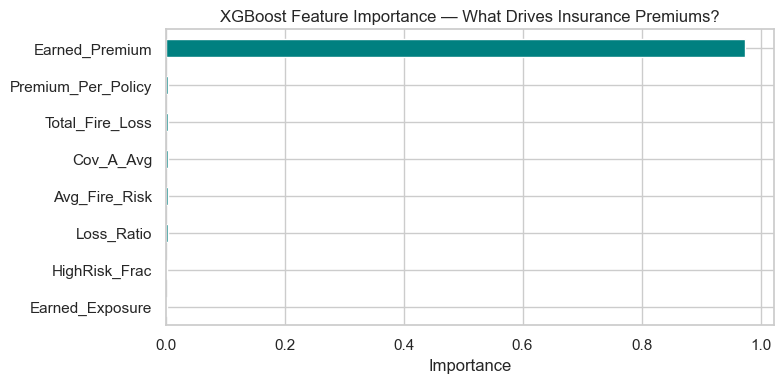

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

scaler_ins = StandardScaler()
X_train_s = scaler_ins.fit_transform(X_train_ins)
X_test_s = scaler_ins.transform(X_test_ins)

classical_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=42),
}

classical_results = {}
for name, model in classical_models.items():
    t0 = time.time()
    model.fit(X_train_s, y_train_ins)
    train_t = time.time() - t0
    y_pred = model.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test_ins, y_pred))
    r2 = r2_score(y_test_ins, y_pred)
    classical_results[name] = {'RMSE': rmse, 'R2': r2, 'Time': train_t, 'preds': y_pred}
    print(f"{name:25s} | RMSE: ${rmse:,.0f} | R²: {r2:.4f} | Time: {train_t:.3f}s")

# Feature importance from XGBoost
xgb_imp = pd.Series(classical_models['XGBoost'].feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
xgb_imp.plot(kind='barh', color='teal', ax=ax)
ax.set_title("XGBoost Feature Importance — What Drives Insurance Premiums?")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../results/insurance_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Quantum Regressor for Premium Prediction (VQR)

### How VQR differs from VQC:
- **VQC** (Task 1A) outputs a class label (fire / no-fire) by measuring qubits
- **VQR** outputs a continuous number by computing the **expectation value** of a quantum observable

Think of it this way: after the quantum circuit runs, instead of asking "which state did it collapse to?" (classification), we ask "what's the average value?" (regression). This average value IS our premium prediction.

### Why we subsample:
Quantum simulation is exponentially expensive. With 6 qubits we simulate 2^6 = 64 states. Each training step evaluates the circuit hundreds of times. So we use a representative subset of ZIP codes.

In [6]:
from sklearn.preprocessing import MinMaxScaler
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQR
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.optimizers import COBYLA

N_QUBITS_INS = 6

# Select top 6 features for quantum model based on XGBoost importance
q_features = xgb_imp.tail(N_QUBITS_INS).index.tolist()
print(f"Quantum features ({N_QUBITS_INS} qubits): {q_features}")

# Prepare quantum-sized subsets
# Scale features to [0, pi] for angle encoding
q_feat_idx = [feature_cols.index(f) for f in q_features]
X_train_qf = X_train_s[:, q_feat_idx]
X_test_qf = X_test_s[:, q_feat_idx]

pi_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_qf = pi_scaler.fit_transform(X_train_qf)
X_test_qf = pi_scaler.transform(X_test_qf)

# Normalize target to [0, 1] for quantum regression
y_scaler = MinMaxScaler(feature_range=(0, 1))
y_train_qn = y_scaler.fit_transform(y_train_ins.reshape(-1, 1)).ravel()
y_test_qn = y_scaler.transform(y_test_ins.reshape(-1, 1)).ravel()

# Subsample for quantum (150 train, 50 test)
np.random.seed(42)
q_train_idx = np.random.choice(len(X_train_qf), size=150, replace=False)
q_test_idx = np.random.choice(len(X_test_qf), size=50, replace=False)

X_trq = X_train_qf[q_train_idx]
y_trq = y_train_qn[q_train_idx]
X_tsq = X_test_qf[q_test_idx]
y_tsq = y_test_qn[q_test_idx]
y_tsq_actual = y_test_ins[q_test_idx]

print(f"Quantum train: {X_trq.shape}, Quantum test: {X_tsq.shape}")

Quantum features (6 qubits): ['Loss_Ratio', 'Avg_Fire_Risk', 'Cov_A_Avg', 'Total_Fire_Loss', 'Premium_Per_Policy', 'Earned_Premium']
Quantum train: (150, 6), Quantum test: (50, 6)


In [7]:
# Build VQR
feature_map_ins = ZZFeatureMap(feature_dimension=N_QUBITS_INS, reps=1)

# RealAmplitudes is a good ansatz for regression — it uses Ry rotations and CNOT gates
ansatz_ins = RealAmplitudes(num_qubits=N_QUBITS_INS, reps=2, entanglement='linear')

print(f"Feature Map: {feature_map_ins.num_qubits} qubits, depth {feature_map_ins.depth()}")
print(f"Ansatz: {ansatz_ins.num_parameters} trainable parameters")

optimizer_ins = COBYLA(maxiter=60)

vqr = VQR(
    feature_map=feature_map_ins,
    ansatz=ansatz_ins,
    optimizer=optimizer_ins,
    estimator=StatevectorEstimator(),
)

print("\nTraining VQR for premium prediction... (may take several minutes)")
t0 = time.time()
vqr.fit(X_trq, y_trq)
vqr_time = time.time() - t0
print(f"VQR training complete in {vqr_time:.1f}s")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Feature Map: 6 qubits, depth 1
Ansatz: 18 trainable parameters

Training VQR for premium prediction... (may take several minutes)


VQR training complete in 43.3s


In [8]:
# VQR Predictions
y_pred_vqr_norm = vqr.predict(X_tsq)
y_pred_vqr = y_scaler.inverse_transform(y_pred_vqr_norm.reshape(-1, 1)).ravel()

rmse_vqr = np.sqrt(mean_squared_error(y_tsq_actual, y_pred_vqr))
r2_vqr = r2_score(y_tsq_actual, y_pred_vqr)
print(f"VQR — RMSE: ${rmse_vqr:,.0f} | R²: {r2_vqr:.4f} | Time: {vqr_time:.1f}s")

# Also run classical models on the same subset for fair comparison
for name, model in classical_models.items():
    y_p = model.predict(X_test_s[q_test_idx])
    rmse_c = np.sqrt(mean_squared_error(y_tsq_actual, y_p))
    r2_c = r2_score(y_tsq_actual, y_p)
    print(f"{name:25s} — RMSE: ${rmse_c:,.0f} | R²: {r2_c:.4f} (same subset)")

VQR — RMSE: $3,046,781 | R²: -0.0317 | Time: 43.3s
Linear Regression         — RMSE: $604,892 | R²: 0.9593 (same subset)


Random Forest             — RMSE: $780,311 | R²: 0.9323 (same subset)
XGBoost                   — RMSE: $730,355 | R²: 0.9407 (same subset)


## Step 6: Quantum Kernel Regression (Alternative Quantum Approach)

Same idea as the quantum kernel from Task 1A, but for regression instead of classification.
We compute pairwise quantum similarity between ZIP codes, then use a kernel ridge regression.

In [9]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.kernel_ridge import KernelRidge

kernel_fm = ZZFeatureMap(feature_dimension=N_QUBITS_INS, reps=1)
qkernel = FidelityQuantumKernel(feature_map=kernel_fm)

print("Computing quantum kernel matrices for regression...")
t0 = time.time()
K_train = qkernel.evaluate(X_trq)
K_test = qkernel.evaluate(X_tsq, X_trq)
qk_time = time.time() - t0
print(f"Kernel computation: {qk_time:.1f}s")

# Kernel Ridge Regression with quantum kernel
krr = KernelRidge(kernel='precomputed', alpha=0.1)
krr.fit(K_train, y_trq)
y_pred_qkr_norm = krr.predict(K_test)
y_pred_qkr = y_scaler.inverse_transform(y_pred_qkr_norm.reshape(-1, 1)).ravel()

rmse_qkr = np.sqrt(mean_squared_error(y_tsq_actual, y_pred_qkr))
r2_qkr = r2_score(y_tsq_actual, y_pred_qkr)
print(f"\nQuantum Kernel Regression — RMSE: ${rmse_qkr:,.0f} | R²: {r2_qkr:.4f}")

Computing quantum kernel matrices for regression...


Kernel computation: 218.8s

Quantum Kernel Regression — RMSE: $1,549,595 | R²: 0.7331


## Step 7: Final Comparison — All Models for Task 2

  TASK 2 RESULTS — Insurance Premium Prediction
               Model      Type    RMSE      R2
   Linear Regression Classical  643386  0.9654
       Random Forest Classical  782084  0.9489
             XGBoost Classical  966413  0.9220
       VQR (Quantum)   Quantum 3046781 -0.0317
Quantum Kernel Ridge   Quantum 1549595  0.7331


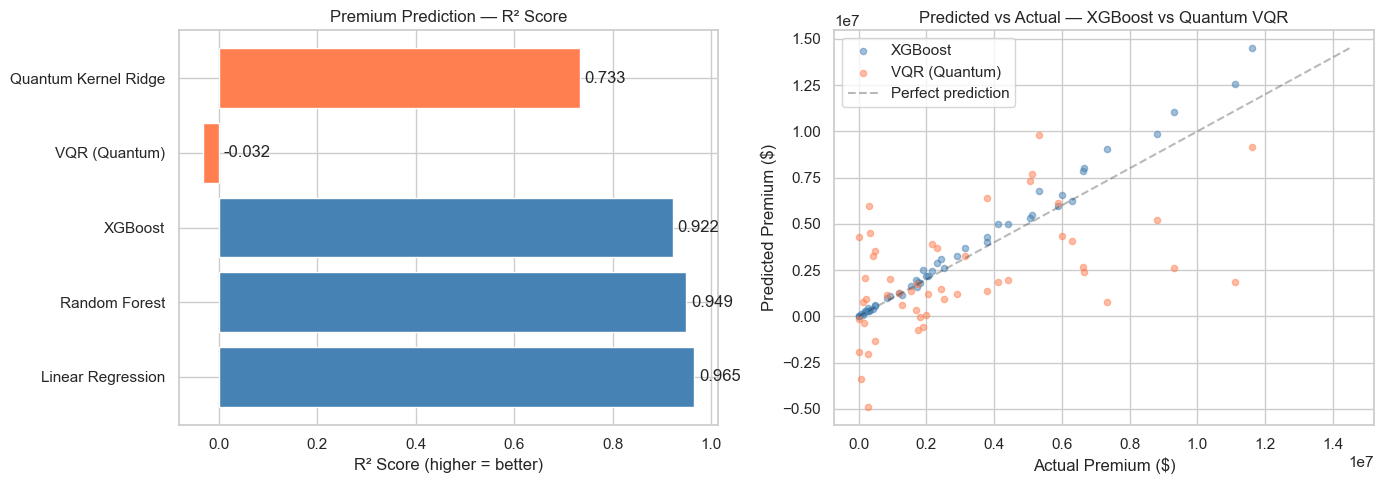


Saved to results/task2_results.csv


In [10]:
import json

# Collect all results
all_results = []
for name, res in classical_results.items():
    all_results.append({'Model': name, 'Type': 'Classical',
                        'RMSE': round(res['RMSE']), 'R2': round(res['R2'], 4)})
all_results.append({'Model': 'VQR (Quantum)', 'Type': 'Quantum',
                    'RMSE': round(rmse_vqr), 'R2': round(r2_vqr, 4)})
all_results.append({'Model': 'Quantum Kernel Ridge', 'Type': 'Quantum',
                    'RMSE': round(rmse_qkr), 'R2': round(r2_qkr, 4)})

results_df = pd.DataFrame(all_results)
print("="*65)
print("  TASK 2 RESULTS — Insurance Premium Prediction")
print("="*65)
print(results_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue' if t == 'Classical' else 'coral' for t in results_df['Type']]

axes[0].barh(results_df['Model'], results_df['R2'], color=colors)
axes[0].set_xlabel('R² Score (higher = better)')
axes[0].set_title('Premium Prediction — R² Score')
for i, v in enumerate(results_df['R2']):
    axes[0].text(max(v + 0.01, 0.01), i, f'{v:.3f}', va='center')

# Predicted vs Actual scatter for best classical and quantum
best_classical = classical_models['XGBoost'].predict(X_test_s[q_test_idx])
axes[1].scatter(y_tsq_actual, best_classical, alpha=0.5, s=20, label='XGBoost', color='steelblue')
axes[1].scatter(y_tsq_actual, y_pred_vqr, alpha=0.5, s=20, label='VQR (Quantum)', color='coral')
max_val = max(y_tsq_actual.max(), best_classical.max(), y_pred_vqr.max())
axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect prediction')
axes[1].set_xlabel('Actual Premium ($)')
axes[1].set_ylabel('Predicted Premium ($)')
axes[1].set_title('Predicted vs Actual — XGBoost vs Quantum VQR')
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/task2_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Save results
results_df.to_csv('../results/task2_results.csv', index=False)
print("\nSaved to results/task2_results.csv")

## Step 8: Premium Trend Visualization by Fire Risk Category

Map how wildfire risk scores relate to premium changes over time — the core insight the competition is looking for.

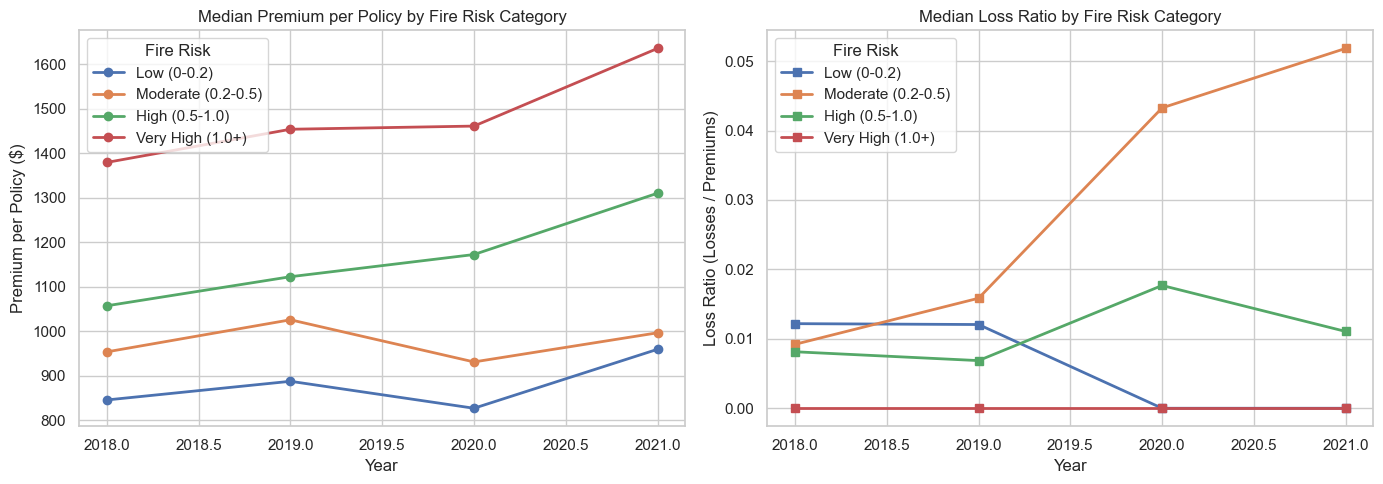

Key insight: Higher fire risk → higher premiums AND higher loss ratios.
This is the risk-premium mapping the competition asks us to model with QML.


In [11]:
# Risk category bins
ins['Risk_Category'] = pd.cut(ins['Avg_Fire_Risk'],
                               bins=[-0.01, 0.2, 0.5, 1.0, 5.0],
                               labels=['Low (0-0.2)', 'Moderate (0.2-0.5)',
                                       'High (0.5-1.0)', 'Very High (1.0+)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Premium trend by risk category
trend = ins.groupby(['Year', 'Risk_Category'])['Premium_Per_Policy'].median().unstack()
trend.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_title("Median Premium per Policy by Fire Risk Category")
axes[0].set_ylabel("Premium per Policy ($)")
axes[0].set_xlabel("Year")
axes[0].legend(title="Fire Risk")

# Loss ratio by risk category
loss_trend = ins.groupby(['Year', 'Risk_Category'])['Loss_Ratio'].median().unstack()
loss_trend.plot(ax=axes[1], marker='s', linewidth=2)
axes[1].set_title("Median Loss Ratio by Fire Risk Category")
axes[1].set_ylabel("Loss Ratio (Losses / Premiums)")
axes[1].set_xlabel("Year")
axes[1].legend(title="Fire Risk")

plt.tight_layout()
plt.savefig("../results/risk_premium_trends.png", dpi=150, bbox_inches='tight')
plt.show()

print("Key insight: Higher fire risk → higher premiums AND higher loss ratios.")
print("This is the risk-premium mapping the competition asks us to model with QML.")